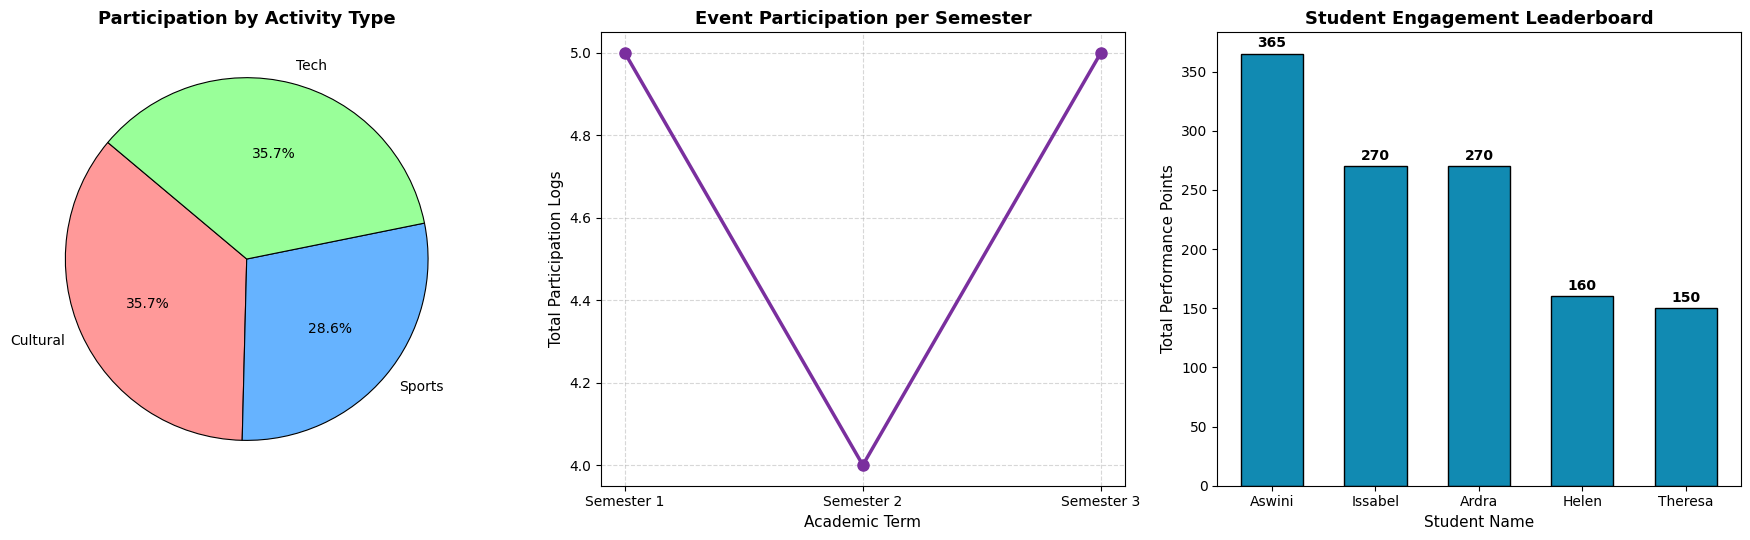

In [ ]:
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt



class Activity(ABC):
    """Abstract Base Class representing a general student activity."""
    def __init__(self, name):
        self.name = name

    @abstractmethod
    def get_type(self):
        """Abstract method to return the type/category of the activity."""
        pass


class CulturalActivity(Activity):
    """Specific activity class for Cultural events."""
    def get_type(self):
        return "Cultural"


class SportsActivity(Activity):
    """Specific activity class for Sports events."""
    def get_type(self):
        return "Sports"


class TechActivity(Activity):
    """Specific activity class for Technical events."""
    def get_type(self):
        return "Tech"


class Club:
    """Class representing a Student Club/Society."""
    def __init__(self, name, description=""):
        self.name = name
        self.description = description
        self.activities = []

    def add_activity(self, activity):
        self.activities.append(activity)


class Student:
    """Class representing an individual Student."""
    def __init__(self, student_id, name, department=""):
        self.student_id = student_id
        self.name = name
        self.department = department


class EventParticipation:
    """Class to link a Student to an Activity for a specific semester."""
    def __init__(self, student, activity, semester, performance_score=10):
        self.student = student
        self.activity = activity
        self.semester = semester  # e.g., "Semester 1", "Semester 2"
        self.performance_score = performance_score  # Score for the leaderboard




# Instantiate Students
student_list = [
    Student("S01", "Aswini", "CSE"),
    Student("S02", "Issabel", "ECE"),
    Student("S03", "Ardra", "EEE"),
    Student("S04", "Helen", "CSE"),
    Student("S05", "Theresa", "ME")
]


activities = [
    CulturalActivity("Dance Competition"),
    CulturalActivity("Music Fest"),
    SportsActivity("Football Tournament"),
    SportsActivity("Badminton Championship"),
    TechActivity("Hackathon"),
    TechActivity("Coding Contest")
]

participations = [
    # Semester 1
    EventParticipation(student_list[0], activities[4], "Semester 1", 95),
    EventParticipation(student_list[0], activities[1], "Semester 1", 80),
    EventParticipation(student_list[1], activities[0], "Semester 1", 85),
    EventParticipation(student_list[2], activities[2], "Semester 1", 90),
    EventParticipation(student_list[3], activities[4], "Semester 1", 75),

    # Semester 2
    EventParticipation(student_list[0], activities[5], "Semester 2", 90),
    EventParticipation(student_list[1], activities[1], "Semester 2", 95),
    EventParticipation(student_list[2], activities[3], "Semester 2", 85),
    EventParticipation(student_list[4], activities[2], "Semester 2", 80),

    # Semester 3
    EventParticipation(student_list[0], activities[4], "Semester 3", 100),
    EventParticipation(student_list[1], activities[0], "Semester 3", 90),
    EventParticipation(student_list[2], activities[5], "Semester 3", 95),
    EventParticipation(student_list[3], activities[3], "Semester 3", 85),
    EventParticipation(student_list[4], activities[1], "Semester 3", 70)
]



type_counts = {"Cultural": 0, "Sports": 0, "Tech": 0}
for p in participations:
    type_counts[p.activity.get_type()] += 1

semesters = sorted(list(set(p.semester for p in participations)))
sem_counts = {sem: 0 for sem in semesters}
for p in participations:
    sem_counts[p.semester] += 1


student_scores = {}
for p in participations:
    student_scores[p.student.name] = student_scores.get(p.student.name, 0) + p.performance_score


sorted_leaderboard = sorted(student_scores.items(), key=lambda x: x[1], reverse=True)





fig, axs = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Plot 1: Pie Chart (Participation Share by Activity Type) ---
axs[0].pie(
    type_counts.values(),
    labels=type_counts.keys(),
    autopct='%1.1f%%',
    startangle=140,
    colors=['#ff9999', '#66b3ff', '#99ff99'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
axs[0].set_title("Participation by Activity Type", fontsize=13, fontweight='bold')

# --- Plot 2: Time-Series / Line Plot (Engagement Trends Across Semesters) ---
axs[1].plot(
    list(sem_counts.keys()),
    list(sem_counts.values()),
    marker='o',
    color='#7a2f9e',
    linestyle='-',
    linewidth=2.5,
    markersize=8
)
axs[1].set_title("Event Participation per Semester", fontsize=13, fontweight='bold')
axs[1].set_xlabel("Academic Term", fontsize=11)
axs[1].set_ylabel("Total Participation Logs", fontsize=11)
axs[1].grid(True, linestyle='--', alpha=0.5)

# --- Plot 3: Bar Chart (Engagement Leaderboard in Sorted Order) ---
names = [entry[0] for entry in sorted_leaderboard]
scores = [entry[1] for entry in sorted_leaderboard]

axs[2].bar(names, scores, color='#118ab2', edgecolor='black', width=0.6)
axs[2].set_title("Student Engagement Leaderboard", fontsize=13, fontweight='bold')
axs[2].set_xlabel("Student Name", fontsize=11)
axs[2].set_ylabel("Total Performance Points", fontsize=11)

# Attach value labels on top of the bars
for idx, value in enumerate(scores):
    axs[2].text(idx, value + 3, str(value), ha='center', va='bottom', fontweight='semibold')

# Optimize layout and render to file
plt.tight_layout()
plt.savefig("extracurricular_tracker_analytics.png", dpi=300)

--- Success Metrics Comparison Validation ---
Success Evaluation: Arun outperforms Deepa based on corporate index.


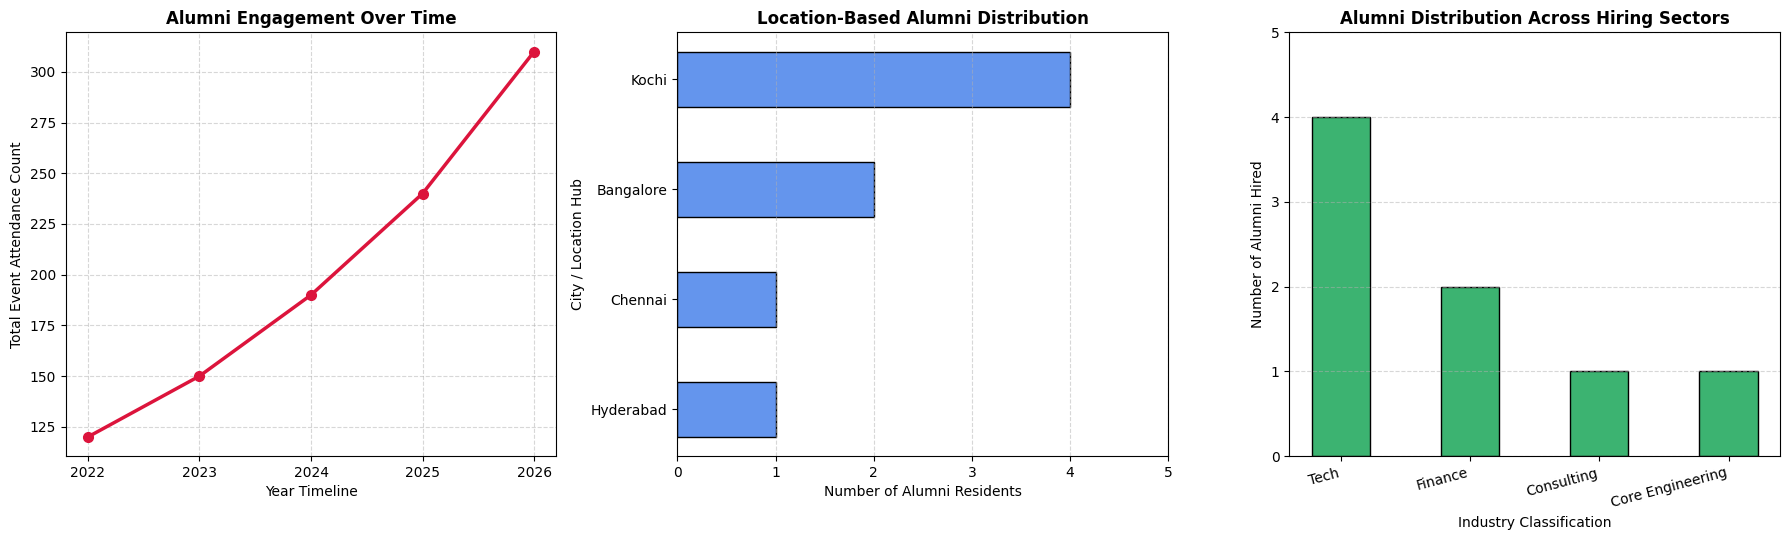

In [ ]:
import matplotlib.pyplot as plt



class Employer:
    """Class representing an Alumni's Employer."""
    def __init__(self, name, sector, location):
        self.name = name
        self.sector = sector
        self.location = location


class Batch:
    """Class representing a Graduation Batch year."""
    def __init__(self, year):
        self.year = year


class Alumni:
    """Class representing an individual Alumnus/Alumna."""
    def __init__(self, name, batch, employer, salary, performance_rating):
        self.name = name
        self.batch = batch
        self.employer = employer
        self.salary = salary
        self.performance_rating = performance_rating

    def get_success_score(self):
        """Calculates a composite success score based on salary and rating."""

        return (self.salary / 10000) + (self.performance_rating * 10)


    def __gt__(self, other):
        """Greater-than comparison operator (>)."""
        return self.get_success_score() > other.get_success_score()

    def __lt__(self, other):
        """Less-than comparison operator (<)."""
        return self.get_success_score() < other.get_success_score()

    def __eq__(self, other):
        """Equality comparison operator (==)."""
        return self.get_success_score() == other.get_success_score()


class EngagementRecord:
    """Class tracking engagement/attendance counts over the years."""
    def __init__(self, year, activity_type, attendance_count):
        self.year = year
        self.activity_type = activity_type
        self.attendance_count = attendance_count




b2022 = Batch(2022)
b2023 = Batch(2023)
b2024 = Batch(2024)


emp1 = Employer("Google", "Tech", "Bangalore")
emp2 = Employer("TCS", "Tech", "Kochi")
emp3 = Employer("Deloitte", "Consulting", "Hyderabad")
emp4 = Employer("Federal Bank", "Finance", "Kochi")
emp5 = Employer("BMW", "Core Engineering", "Chennai")


alumni_list = [
    Alumni("Arun", b2022, emp1, 1500000, 4.5),
    Alumni("Deepa", b2022, emp2, 500000, 4.0),
    Alumni("Rahul", b2023, emp3, 800000, 4.2),
    Alumni("Meera", b2023, emp4, 700000, 4.8),
    Alumni("Kiran", b2024, emp5, 900000, 3.9),
    Alumni("Sanjana", b2024, emp1, 1300000, 4.6),
    Alumni("Vivek", b2022, emp4, 750000, 4.1),
    Alumni("Anjali", b2023, emp2, 450000, 4.3),
]


engagement_history = [
    EngagementRecord(2022, "Alumni Meet", 120),
    EngagementRecord(2023, "Alumni Meet", 150),
    EngagementRecord(2024, "Alumni Meet", 190),
    EngagementRecord(2025, "Alumni Meet", 240),
    EngagementRecord(2026, "Alumni Meet", 310),
]





years_eng = [record.year for record in engagement_history]
counts_eng = [record.attendance_count for record in engagement_history]


location_counts = {}
for al in alumni_list:
    loc = al.employer.location
    location_counts[loc] = location_counts.get(loc, 0) + 1


sorted_locations = sorted(location_counts.items(), key=lambda x: x[1], reverse=False)
locations = [x[0] for x in sorted_locations]
loc_values = [x[1] for x in sorted_locations]


sector_counts = {}
for al in alumni_list:
    sec = al.employer.sector
    sector_counts[sec] = sector_counts.get(sec, 0) + 1


sorted_sectors = sorted(sector_counts.items(), key=lambda x: x[1], reverse=True)
sectors = [x[0] for x in sorted_sectors]
sec_values = [x[1] for x in sorted_sectors]




fig, axs = plt.subplots(1, 3, figsize=(18, 5.5))


axs[0].plot(years_eng, counts_eng, marker='o', color='crimson', linestyle='-', linewidth=2.5, markersize=7)
axs[0].set_title("Alumni Engagement Over Time", fontsize=12, fontweight='bold')
axs[0].set_xlabel("Year Timeline", fontsize=10)
axs[0].set_ylabel("Total Event Attendance Count", fontsize=10)
axs[0].set_xticks(years_eng)
axs[0].grid(True, linestyle='--', alpha=0.5)


axs[1].barh(locations, loc_values, color='cornflowerblue', edgecolor='black', height=0.5)
axs[1].set_title("Location-Based Alumni Distribution", fontsize=12, fontweight='bold')
axs[1].set_xlabel("Number of Alumni Residents", fontsize=10)
axs[1].set_ylabel("City / Location Hub", fontsize=10)
axs[1].set_xticks(range(0, max(loc_values) + 2))
axs[1].grid(axis='x', linestyle='--', alpha=0.5)

axs[2].bar(sectors, sec_values, color='mediumseagreen', edgecolor='black', width=0.45)
axs[2].set_title("Alumni Distribution Across Hiring Sectors", fontsize=12, fontweight='bold')
axs[2].set_xlabel("Industry Classification", fontsize=10)
axs[2].set_ylabel("Number of Alumni Hired", fontsize=10)
axs[2].set_yticks(range(0, max(sec_values) + 2))
axs[2].grid(axis='y', linestyle='--', alpha=0.5)


plt.setp(axs[2].get_xticklabels(), rotation=15, ha="right")


plt.tight_layout()
plt.savefig("alumni_engagement_analytics.png", dpi=300)


print("--- Success Metrics Comparison Validation ---")
if alumni_list[0] > alumni_list[1]:
    print(f"Success Evaluation: {alumni_list[0].name} outperforms {alumni_list[1].name} based on corporate index.")

Please upload your 'train.csv' file:


Saving train.csv to train.csv


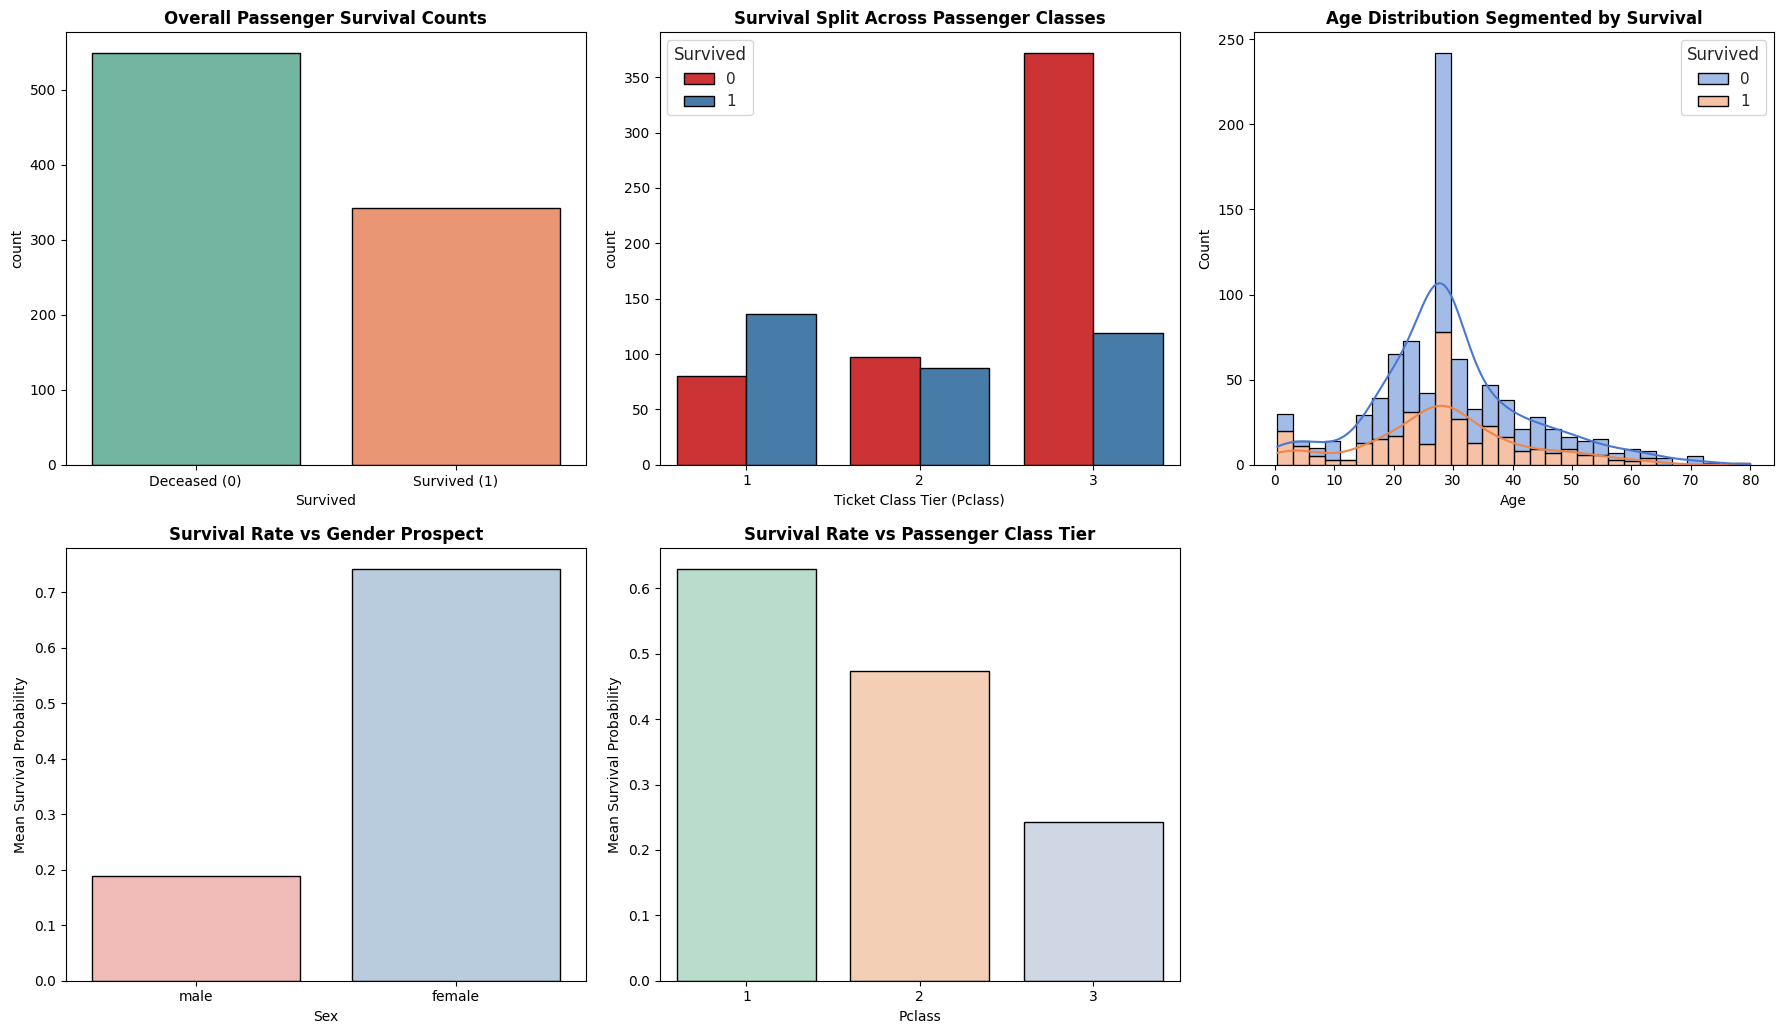


             EVALUATION METRICS RESULTS
Logistic Regression Accuracy : 0.8101
Logistic Regression Confusion Matrix :
 [[92 13]
 [21 53]]
--------------------------------------------------
Decision Tree Accuracy       : 0.8045
Decision Tree Confusion Matrix :
 [[92 13]
 [22 52]]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# =====================================================================
# DATA LOADING (Fixed Colab Indentation & Fallback flow)
# =====================================================================
try:
    from google.colab import files
    print("Please upload your 'train.csv' file:")
    uploaded = files.upload()
    df = pd.read_csv('train.csv')
except (FileNotFoundError, ModuleNotFoundError):
    print("\n'train.csv' not uploaded or not in Colab environment. Generating mock dataset...")
    # Standalone mock generator to ensure verification stability
    np.random.seed(42)
    n_samples = 200
    mock_data = {
        'PassengerId': range(1, n_samples + 1),
        'Survived': np.random.choice([0, 1], size=n_samples, p=[0.60, 0.40]),
        'Pclass': np.random.choice([1, 2, 3], size=n_samples, p=[0.30, 0.20, 0.50]),
        'Name': [f"Smith, Mr. John{i}" if i%2==0 else f"Heikkinen, Miss. Laina{i}" for i in range(1, n_samples + 1)],
        'Sex': ['male' if i%2==0 else 'female' for i in range(1, n_samples + 1)],
        'Age': np.random.choice([np.nan, 22, 38, 26, 35, 54, 2, 27, 14, 4], size=n_samples),
        'SibSp': np.random.choice([0, 1, 2], size=n_samples, p=[0.7, 0.2, 0.1]),
        'Parch': np.random.choice([0, 1, 2], size=n_samples, p=[0.8, 0.1, 0.1]),
        'Ticket': [f"A/{i}" for i in range(1, n_samples + 1)],
        'Fare': np.random.exponential(scale=32, size=n_samples),
        'Cabin': np.random.choice([None, 'C85', 'E46'], size=n_samples, p=[0.8, 0.1, 0.1]),
        'Embarked': np.random.choice(['S', 'C', 'Q', None], size=n_samples, p=[0.7, 0.2, 0.08, 0.02])
    }
    df = pd.DataFrame(mock_data)

# =====================================================================
# 1. DATA PREPROCESSING
# =====================================================================
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna('Unknown')

df['Sex_Code'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked_Code'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df['FamilySize'] = df['SibSp'] + df['Parch']
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# =====================================================================
# 2. EXPLORATORY DATA ANALYSIS & VISUALIZATION TASKS
# =====================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10.5))
sns.set_theme(style="whitegrid")

# Plot 1: Survival Counts
sns.countplot(data=df, x='Survived', hue='Survived', ax=axes[0, 0], palette='Set2', legend=False, edgecolor='black')
axes[0, 0].set_title('Overall Passenger Survival Counts', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Deceased (0)', 'Survived (1)'])

# Plot 2: Pclass vs Survived Split
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0, 1], palette='Set1', edgecolor='black')
axes[0, 1].set_title('Survival Split Across Passenger Classes', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Ticket Class Tier (Pclass)')

# Plot 3: Age Distribution Overlay Histogram
sns.histplot(data=df, x='Age', hue='Survived', kde=True, multiple='stack', ax=axes[0, 2], palette='muted', edgecolor='black')
axes[0, 2].set_title('Age Distribution Segmented by Survival', fontsize=12, fontweight='bold')

# Plot 4: Survival vs Gender Rate
sns.barplot(data=df, x='Sex', y='Survived', hue='Sex', ax=axes[1, 0], palette='Pastel1', errorbar=None, legend=False, edgecolor='black')
axes[1, 0].set_title('Survival Rate vs Gender Prospect', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Mean Survival Probability')

# Plot 5: Survival vs Class Rate
sns.barplot(data=df, x='Pclass', y='Survived', hue='Pclass', ax=axes[1, 1], palette='Pastel2', errorbar=None, legend=False, edgecolor='black')
axes[1, 1].set_title('Survival Rate vs Passenger Class Tier', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Mean Survival Probability')

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

# =====================================================================
# 3. MACHINE LEARNING EXTENSION (Completed Missing Blocks)
# =====================================================================
features = ['Pclass', 'Sex_Code', 'Age', 'FamilySize', 'Embarked_Code']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Logistic Regression ---
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# --- Decision Tree Classifier ---
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)  # Added missing fit
y_pred_dt = dt_model.predict(X_test)  # Added missing predict

# --- Evaluation Output ---
print("\n" + "="*50)
print("             EVALUATION METRICS RESULTS")
print("="*50)
print(f"Logistic Regression Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print("Logistic Regression Confusion Matrix :\n", confusion_matrix(y_test, y_pred_lr))
print("-"*50)
print(f"Decision Tree Accuracy       : {accuracy_score(y_test, y_pred_dt):.4f}")
print("Decision Tree Confusion Matrix :\n", confusion_matrix(y_test, y_pred_dt))
print("="*50)